# Data Import & Preprocessing
https://www.kaggle.com/c/GiveMeSomeCredit/data

In [35]:
pip install -U pymoo --quiet

Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [37]:
pip install fairlearn --quiet

Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install fairlearn matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [39]:
pip install opendatasets --quiet

Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install EMP-PY --quiet

Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# from google.colab import drive
import opendatasets as od
import xgboost as xgb
from xgboost import XGBClassifier

# Cell output settings
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
warnings.filterwarnings("ignore")

# Get data from kaggle
# username:christoskestritsalis || key:3b3e38e852c4a2f564509e05994e4054
od.download("https://www.kaggle.com/c/GiveMeSomeCredit/data")
df = pd.read_csv('GiveMeSomeCredit/cs-training.csv')

# sample 50% of dataset
# df = df.sample(frac=0.5)

print(df.shape)
df.head()

Skipping, found downloaded files in ".\GiveMeSomeCredit" (use force=True to force download)
(150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [42]:
# check for NAs
na_rows = df[df.isna().any(axis=1)]
print(na_rows.shape)

# impute mean for NAs
df = df.fillna(df.mean())

# confirm no NAs left
na_rows = df[df.isna().any(axis=1)]
print(na_rows.shape)

(29731, 12)
(0, 12)


In [43]:
# split X, y
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

print(X.shape, y.shape)

(150000, 11) (150000,)


In [44]:
from sklearn.model_selection import train_test_split

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, y_train.shape)

(105000, 11) (105000,)


# Optimization

In [45]:
# %%time

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# ### RF Grid Search ###
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(estimator=RandomForestClassifier(),
#                            param_grid=param_grid,
#                            cv=5,  # Number of cross-validation folds
#                            scoring='accuracy',  # Metric to optimize
#                            verbose=2,  # Print progress
#                            n_jobs=-1)  # Use all available cores


# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_) # [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]
# print("Best Score:", grid_search.best_score_)

# rf_params = grid_search.best_params_
# # rf_params_list = [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]

# rf_params

## EMP

In [46]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from EMP.metrics import empCreditScoring

### EMP func ###
def emp_func(no_of_features, direction="forward"):
  # FS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features,
                                 direction=direction)
  fs.fit(X_train, y_train)
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)

  # print("Features selected: ", fs.get_feature_names_out())

  # train classification model with selected features
  clf = XGBClassifier(colsample_bytree= 1.0, gamma= 0, learning_rate= 0.1, max_depth= 5, n_estimators= 50, subsample= 0.8).fit(X_train_new, y_train) # params based on acc

  scores = clf.predict_proba(X_test_new)[:, 1] # y_pred_proba
  classes = y_test.values

  emp_score = empCreditScoring(scores, classes, rounding=3) # Will print and return output with k decimal points

  print("number of features: ", no_of_features, ", EMP: ", emp_score)

  return emp_score[0]

In [47]:
emp_func(3)

number of features:  3 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)


0.003

In [48]:
%%time

# create results dict
results_emp = {}

for i in range(1, len(X.columns)):
  results_emp[i] = emp_func(i)

# print(results_emp)

# converto to pd Series
df_res_emp = pd.Series(results_emp)

df_res_emp.head()

number of features:  1 , EMP:  output(EMPC=0.002, EMPC_fraction=0.012)
number of features:  2 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)
number of features:  3 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)
number of features:  4 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  6 , EMP:  output(EMPC=0.003, EMPC_fraction=0.022)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  8 , EMP:  output(EMPC=0.003, EMPC_fraction=0.022)
number of features:  9 , EMP:  output(EMPC=0.004, EMPC_fraction=0.022)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
CPU times: total: 6h 30min 2s
Wall time: 1h 27min 22s


1    0.002
2    0.003
3    0.003
4    0.003
5    0.003
dtype: float64

In [49]:
emp_scores_list = []

for i in range(1, len(X_train.columns)):
  emp_scores_list.append(emp_func(i))

number of features:  1 , EMP:  output(EMPC=0.002, EMPC_fraction=0.012)
number of features:  2 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)
number of features:  3 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)
number of features:  4 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  5 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  6 , EMP:  output(EMPC=0.003, EMPC_fraction=0.022)
number of features:  7 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
number of features:  8 , EMP:  output(EMPC=0.003, EMPC_fraction=0.022)
number of features:  9 , EMP:  output(EMPC=0.004, EMPC_fraction=0.022)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)


## Fairness

In [50]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

### Fairness Function ###
# https://fairlearn.org/v0.10/quickstart.html

def fair_func(no_of_features): # !!! fix fairness calc

  # FS: SFS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features)
  fs.fit(X_train, y_train)

  # create new X_train and X_test based on selected features
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)
  # print("Features selected: ", fs.get_feature_names_out())

  # classification
  #clf = XGBClassifier(colsample_bytree= 1.0,
  #                    gamma= 0,
  #                    learning_rate= 0.1,
  #                max_depth= 5,
  #                    n_estimators= 50,
  #                    subsample= 0.8)
  clf = RandomForestClassifier() # as otherwise fairness score always same
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  mf = MetricFrame(metrics=accuracy_score, # [selection_rate, accuracy_score]
                  y_true=y_test,
                  y_pred=y_pred,
                  sensitive_features=X_test["NumberOfDependents"] # A6 seems to be some kind of grouping # can be categorical
                  )

  fair_score = mf.overall.round(3)
  # fair_score_group = mf.by_group

  print("number of features: ", no_of_features, ", fairness: ", fair_score)

  return fair_score

fair_func(3)

number of features:  3 , fairness:  0.936


0.936

In [51]:
%%time

# create results dict
results_fair = {}

for i in range(1, len(X.columns)):
  results_fair[i] = fair_func(i)

# print(results_emp)

# converto to pd Series
df_res_fair = pd.Series(results_fair)

df_res_fair.head()

number of features:  1 , fairness:  0.937
number of features:  2 , fairness:  0.936
number of features:  3 , fairness:  0.936
number of features:  4 , fairness:  0.937
number of features:  5 , fairness:  0.937
number of features:  6 , fairness:  0.936
number of features:  7 , fairness:  0.936
number of features:  8 , fairness:  0.936
number of features:  9 , fairness:  0.937
number of features:  10 , fairness:  0.937
CPU times: total: 8h 3min 12s
Wall time: 1h 13min 38s


1    0.937
2    0.936
3    0.936
4    0.937
5    0.937
dtype: float64

In [52]:
fair_scores_list = []

for i in range(1, len(X_train.columns)):
  fair_scores_list.append(fair_func(i))

number of features:  1 , fairness:  0.937
number of features:  2 , fairness:  0.936
number of features:  3 , fairness:  0.936
number of features:  4 , fairness:  0.936
number of features:  5 , fairness:  0.936
number of features:  6 , fairness:  0.936
number of features:  7 , fairness:  0.937
number of features:  8 , fairness:  0.937
number of features:  9 , fairness:  0.937
number of features:  10 , fairness:  0.937


# 1-Obj Opti

In [53]:
emp_scores = df_res_emp.tolist()

# max value from results dict/list
max_emp = max(emp_scores) # emp_scores, df_res_emp, results_emp
max_emp_ind = emp_scores.index(max(emp_scores))+1
max_emp_perc = round(max_emp_ind/(len(emp_scores)+1), 3)*100

print("maximum EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores)+1,
      " features used(", max_emp_perc,"%)")
print("fairness w/ max.EMP feature count:", results_fair[max_emp_ind])
print("CPU time: ")

maximum EMP:  0.004 ,  9 / 11  features used( 81.8 %)
fairness w/ max.EMP feature count: 0.937
CPU time: 


In [54]:
%%time
emp_func(max_emp_ind)

number of features:  9 , EMP:  output(EMPC=0.004, EMPC_fraction=0.022)
CPU times: total: 1h 20min 1s
Wall time: 10min 52s


0.004

Text(0, 0.5, 'EMP')

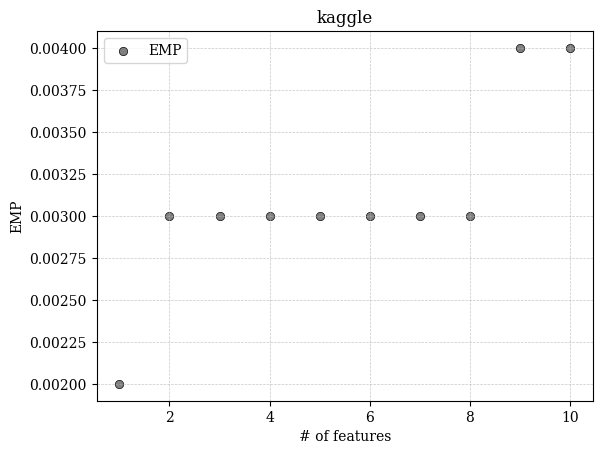

In [69]:
# TODO: format maximum value (solution)
# TODO: add data labels for max
# TODO: add AUC and/or Acc on plot

# Scatterplot EMP - # Features
sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color = "grey", edgecolor="black")

# add second axis to plot
# ax2 = plt.twinx()
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_auc, label="AUC", color="orange", ax=ax2, alpha=0.5, s=20) # size=
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_acc, label="Acc", color="green", ax=ax2, alpha=0.2)

plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7) 
plt.legend() #loc="upper left"
plt.title('kaggle')
plt.xlabel('# of features')
plt.ylabel('EMP')

# 2-Obj Opti

In [71]:
from pymoo.problems.functional import FunctionalProblem

# problem def & opti, plot
max_n_features = max(results_emp.keys())

def restrain_integer_sampling(n_features):
  if n_features > max_n_features:
    return max_n_features
  elif n_features < 1:
    return 1
  else:
    return n_features

def calculate_emp(n_features):
  return -1*results_emp[n_features]

def minimize_n_features(n_features):
  return n_features

def maximize_fairness(n_features):
  return -1*results_fair[n_features]

In [72]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    # lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    # constr_ieq=constr_ieq,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.003  3.   ]]



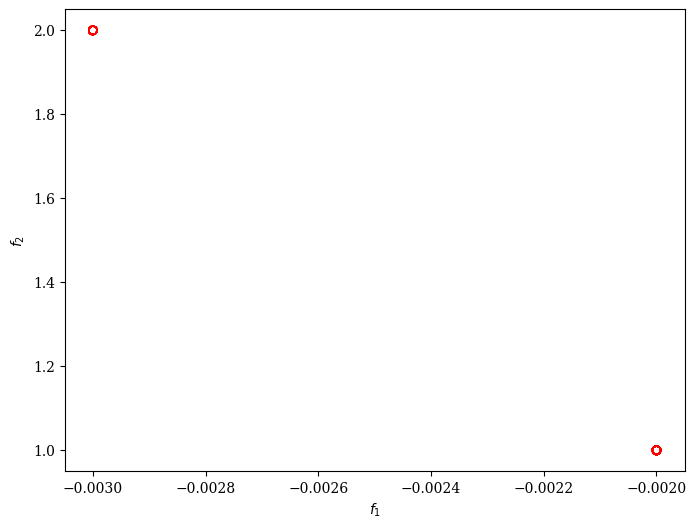

In [73]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()
#plt.title("2-Obj Opti")
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
#plt.gca().invert_xaxis()
#plt.grid(True)

plot.show()

In [74]:
# calculate number of features for best solution
emp_list_2obj = [abs(i) for i, j in res.F]
fs_counts_2obj = [j for i, j in res.F]

max_emp_2obj = max(emp_list_2obj)
max_fs_counts_2obj = int(max(fs_counts_2obj))
# print("Number of features:", max_fs_counts)

# Output
print("2-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp_2obj)

# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts_2obj))

2-Obj Opti Results: 

max EMP: 0.003
number of features:  2 , fairness:  0.937
Fairness score: 0.937


In [75]:
%%time
emp_func(max_fs_counts_2obj)

number of features:  2 , EMP:  output(EMPC=0.003, EMPC_fraction=0.019)
CPU times: total: 7min 44s
Wall time: 47.5 s


0.003

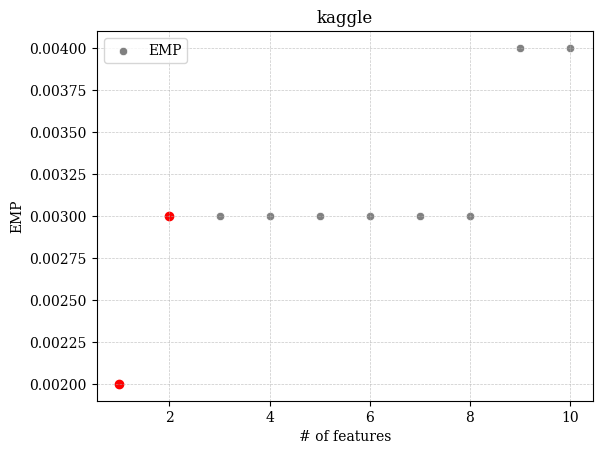

In [76]:
### plot w/SO scatter ###

def plot_solution(X_train, df_res_emp, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color="grey")

  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
  plt.legend() #loc="upper left"
  plt.title('kaggle')
  plt.xlabel('# of features')
  plt.ylabel('EMP')

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Special Point')
    pass

# plot_solution(X_train, df_res_emp, max_fs_counts) # visualizes solution, not set of soltions-->vis res.F
plot_solution(X_train, df_res_emp, np.unique(res.F[:, 1]))

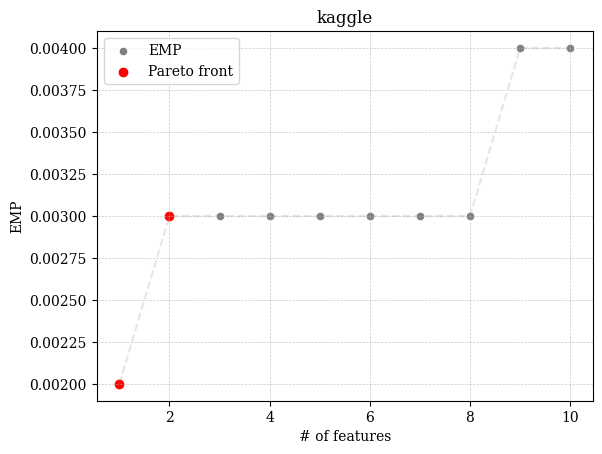

In [77]:
### plot w/SO scatter ###

def plot_solution_2d(x, y, parameters={}, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=x, y=y, label=parameters.get('label'), color='grey')
  plt.plot(x, y, linestyle='--', color='grey', alpha=0.2)  # Add connecting line


  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)

  plt.title(parameters.get('title'))
  plt.xlabel(parameters.get('x_label'))
  plt.ylabel(parameters.get('y_label'))

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Pareto front')

  plt.legend() #loc="upper left"

parameters = {
    'label': "EMP",
    'title': 'kaggle',
    'x_label': '# of features',
    'y_label': 'EMP',
}
plot_solution_2d(list(range(1, len(X_train.columns))), df_res_emp, parameters, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

# 3-Obj Opti

In [79]:
# problem def & opti, plot

In [80]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.003  3.    -0.936]]



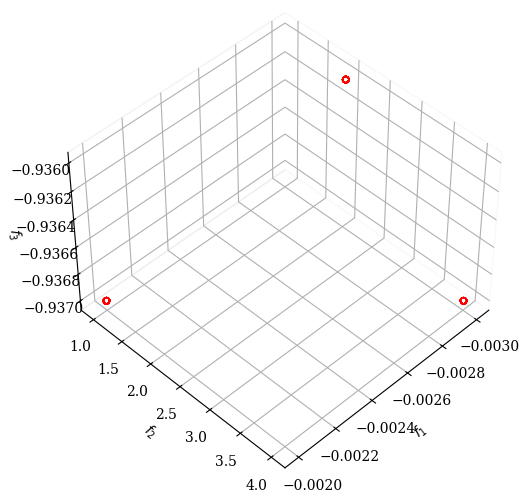

In [81]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()
# plt.title("3-Obj Opti")
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
# plt.gca().invert_xaxis()

plot.show()

In [82]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j, k in res.F]
fs_counts = [j for i, j, k in res.F]
fair_scores = [k for i, j, k in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

### OUTPUT ###
print("3-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts))

3-Obj Opti Results: 

max EMP: 0.003
number of features:  4 , fairness:  0.937
Fairness score: 0.937


In [83]:
%%time
emp_func(max_fs_counts)

number of features:  4 , EMP:  output(EMPC=0.003, EMPC_fraction=0.021)
CPU times: total: 28min 33s
Wall time: 2min 56s


0.003

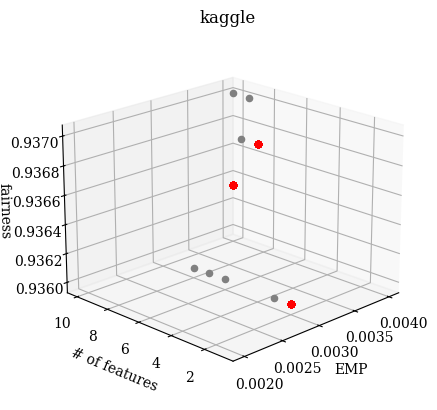

In [84]:
def plot_solution_3d(x, y, z, point_labels, parameters={}, highlight_indices=None):
  # Create a figure and a 3D subplot
  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  # Create the 3D scatter plot using Seaborn's color palette
  # darkgrid, whitegrid, dark, white, ticks
  sns.set_style("ticks") # Set Seaborn style
  # ax.scatter(x, y, z, c=z, cmap=sns.color_palette("viridis", as_cmap=True))  # Color points by z-value

  grey_idx = point_labels == "2-obj"
  red_idx = point_labels == "3-obj"
  ax.scatter(x[grey_idx], y[grey_idx], z[grey_idx], c="grey", depthshade=False)  # Color points by z-value
  ax.scatter(x[red_idx], y[red_idx], z[red_idx], c="red", depthshade=False)  # Color points by z-value
  ax.view_init(elev=20, azim=225) # Example angles

  # Set labels and title
  ax.set_xlabel(parameters.get("x_label"))
  ax.set_ylabel(parameters.get("y_label"))
  ax.set_zlabel(parameters.get("z_label"))
  ax.set_title(parameters.get("title"))

  plt.show()


# Convert results to 3D DataFrame -- 3-Obj
res_f_df = pd.DataFrame(res.F, columns=["f1", "f2", "f3"])
res_f_df = res_f_df.abs()
res_f_df["label"] = "3-obj"


# Convert the Series to 3D DataFrame - 2-Obj
df_res_emp_for_3d = pd.DataFrame(df_res_emp, columns=['f1'])  # Series to DataFrame
df_res_emp_for_3d["f2"] = range(1, len(df_res_emp)+1) # Add 'f2' column
df_res_emp_for_3d["f3"] = df_res_fair # Add 'f3' column
df_res_emp_for_3d["label"] = "2-obj"
df_res_emp_for_3d = df_res_emp_for_3d[["f1", "f2", "f3", "label"]]

merged_results = pd.concat([res_f_df, df_res_emp_for_3d], axis=0)

# res_f_df_1st_dim = res_f_df.iloc[:, 0]
# res_f_df_2nd_dim = res_f_df.iloc[:, 1]
# res_f_df_3rd_dim = res_f_df.iloc[:, 2]

df_1st_dim = merged_results.iloc[:, 0]
df_2nd_dim = merged_results.iloc[:, 1]
df_3rd_dim = merged_results.iloc[:, 2]
df_point_labels = merged_results.iloc[:, 3]

plot_solution_3d(
    x=df_1st_dim,
    y=df_2nd_dim,
    z=df_3rd_dim,
    point_labels=df_point_labels,
    parameters={'label': "EMP", 'title': 'kaggle', 'x_label': 'EMP', 'y_label': '# of features', 'z_label': 'fairness'}
)

# All Features

In [67]:
%%time

print("EMP with all features:", results_emp[max(results_emp.keys())])
print("# features used: ", len(X_train.columns))
print("Fairness with all feats:", results_fair[max(results_fair.keys())])
print("CPU time:",)
%timeit emp_func(len(X.columns)-1)

EMP with all features: 0.004
# features used:  11
Fairness with all feats: 0.937
CPU time:
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
13min 40s ± 59.8 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: total: 11h 39min 11s
Wall time: 1h 49min 21s


In [68]:
%%timeit

emp_func(len(X.columns)-1)

number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
number of features:  10 , EMP:  output(EMPC=0.004, EMPC_fraction=0.023)
11min 24s ± 1min 35s per loop (mean ± std. dev. of 7 runs, 1 loop each)
